# 01 — Exploratory Data Analysis (Fraud Detection)

Goal: understand the fraud signal before modelling — **class imbalance**, **feature
missingness**, and **temporal fraud density** (the three things a fraud reviewer asks first).

This notebook runs on the real **IEEE-CIS** data when it has been downloaded
(`python -m fraud.data.download --dataset ieee-cis`), and otherwise transparently falls
back to a **synthetic IEEE-CIS-shaped dataset** so the analysis is reproducible offline.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")   # make 'src' importable when running from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from fraud.data.load import load_ieee_cis, IEEE_TARGET, add_transaction_datetime
from fraud.data.synthetic import make_ieee_like

try:
    df = load_ieee_cis(nrows=200_000)
    SOURCE = "IEEE-CIS (real)"
except FileNotFoundError:
    df = add_transaction_datetime(make_ieee_like(60_000, seed=11))
    SOURCE = "synthetic (IEEE-CIS-shaped)"

print(f"source : {SOURCE}")
print(f"shape  : {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head(3)

source : synthetic (IEEE-CIS-shaped)
shape  : 60,000 rows x 24 cols


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card4,card6,addr1,...,C2,C13,C14,D1,D4,D15,DeviceType,transaction_dt,hour,day_of_week
0,1,0,87447,56.6900,W,15193,586.0000,visa,debit,486.0000,...,0.0000,1.0000,3.0000,496.0000,NaN,488.0000,None,2017-12-02 00:17:27,0,5
1,2,0,87449,243.6500,C,3137,458.0000,mastercard,credit,391.0000,...,4.0000,6.0000,2.0000,316.0000,353.0000,175.0000,desktop,2017-12-02 00:17:29,0,5
2,3,0,87555,210.0200,W,3851,292.0000,mastercard,debit,178.0000,...,0.0000,3.0000,3.0000,49.0000,NaN,626.0000,desktop,2017-12-02 00:19:15,0,5


## 1. Class imbalance — how rare is fraud?

fraud rate: 3.550%   (2,130 fraud / 60,000 total)
imbalance ratio: 1 fraud per 27 legitimate


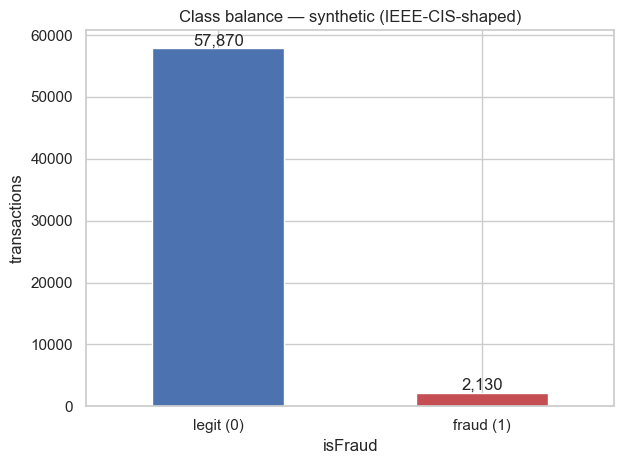

In [3]:
rate = df[IEEE_TARGET].mean()
counts = df[IEEE_TARGET].value_counts().sort_index()
print(f"fraud rate: {rate:.3%}   ({counts.get(1,0):,} fraud / {len(df):,} total)")
print(f"imbalance ratio: 1 fraud per {((1-rate)/rate):.0f} legitimate")

ax = counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["legit (0)", "fraud (1)"], rotation=0)
ax.set_title(f"Class balance — {SOURCE}")
ax.set_ylabel("transactions")
for i, v in enumerate(counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

**Takeaway:** fraud is ~0.2–4% of rows. Accuracy is useless here; we optimise
**recall at a capped false-positive rate (FPR ≤ 2%)** and handle imbalance with class
weights / resampling (compared in `03_benchmark`).

## 2. Feature missingness

5 of 24 columns contain missing values


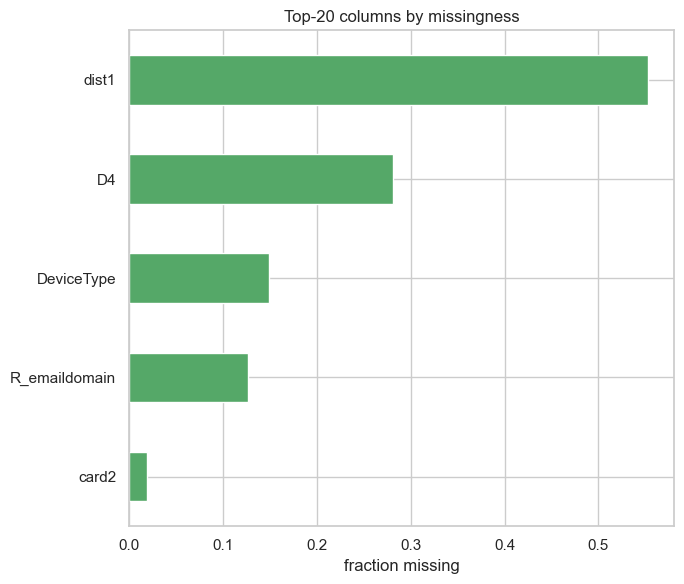

In [4]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0].head(20)
print(f"{(df.isna().mean() > 0).sum()} of {df.shape[1]} columns contain missing values")

ax = miss.plot(kind="barh", color="#55A868", figsize=(7, 6))
ax.invert_yaxis()
ax.set_title("Top-20 columns by missingness")
ax.set_xlabel("fraction missing")
plt.tight_layout(); plt.show()

**Takeaway:** identity/device columns are sparsely populated — and *missingness itself
is predictive* (a blank recipient e-mail or device fingerprint is a risk signal). We encode
missing categoricals as an explicit `"missing"` category rather than dropping them.

## 3. Transaction amount by class

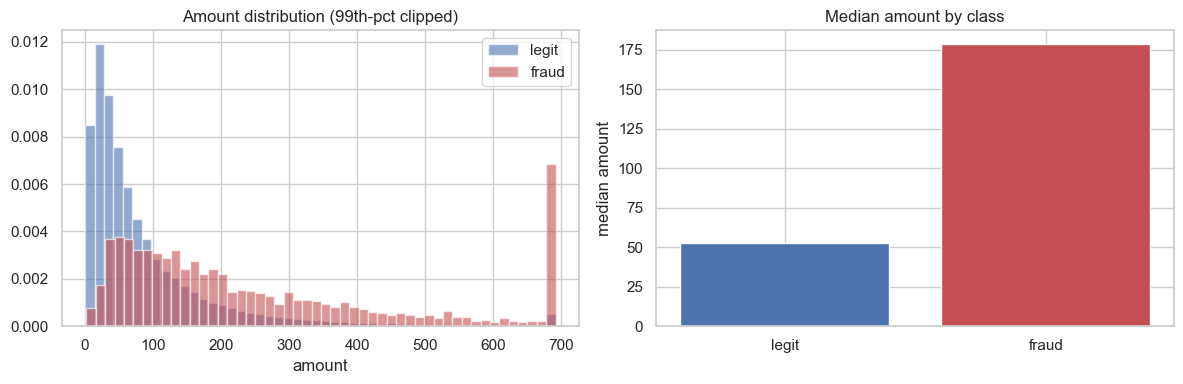

            mean      50%         max
isFraud                              
0        92.3896  52.7150  6,226.1000
1       296.1763 178.2350 11,642.6100


In [5]:
amt = "TransactionAmt"
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for cls, color, label in [(0, "#4C72B0", "legit"), (1, "#C44E52", "fraud")]:
    sub = df.loc[df[IEEE_TARGET] == cls, amt].clip(upper=df[amt].quantile(0.99))
    ax[0].hist(sub, bins=50, alpha=0.6, density=True, color=color, label=label)
ax[0].set_title("Amount distribution (99th-pct clipped)"); ax[0].set_xlabel("amount"); ax[0].legend()

med = df.groupby(IEEE_TARGET)[amt].median()
ax[1].bar(["legit", "fraud"], med.values, color=["#4C72B0", "#C44E52"])
ax[1].set_title("Median amount by class"); ax[1].set_ylabel("median amount")
plt.tight_layout(); plt.show()
print(df.groupby(IEEE_TARGET)[amt].describe()[["mean","50%","max"]])

## 4. Temporal fraud density

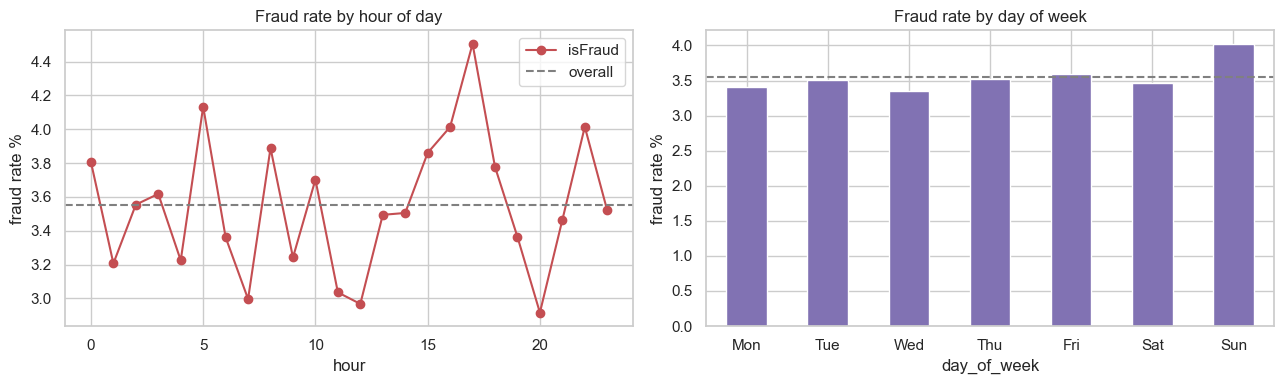

In [6]:
if "hour" not in df.columns:
    df = add_transaction_datetime(df)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
by_hour = df.groupby("hour")[IEEE_TARGET].mean() * 100
by_hour.plot(ax=ax[0], marker="o", color="#C44E52")
ax[0].axhline(df[IEEE_TARGET].mean()*100, ls="--", color="grey", label="overall")
ax[0].set_title("Fraud rate by hour of day"); ax[0].set_ylabel("fraud rate %"); ax[0].legend()

by_dow = df.groupby("day_of_week")[IEEE_TARGET].mean() * 100
by_dow.plot(kind="bar", ax=ax[1], color="#8172B3")
ax[1].axhline(df[IEEE_TARGET].mean()*100, ls="--", color="grey")
ax[1].set_title("Fraud rate by day of week"); ax[1].set_ylabel("fraud rate %")
ax[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)
plt.tight_layout(); plt.show()

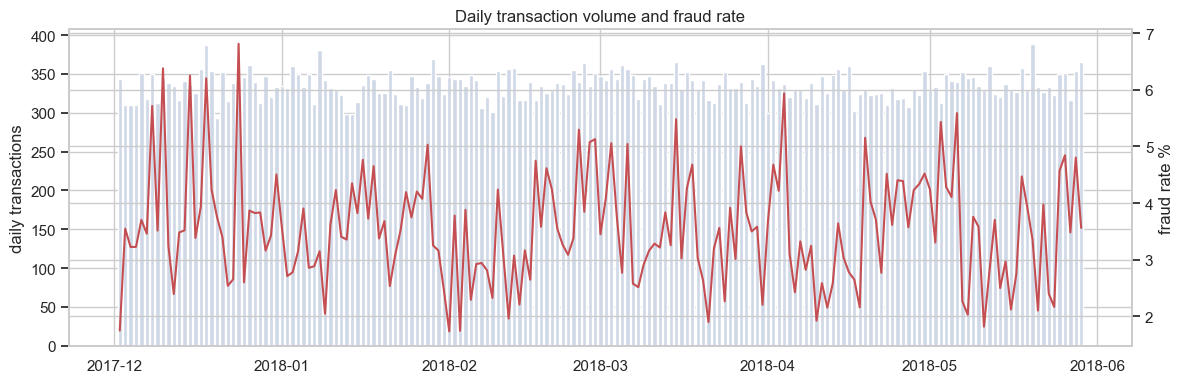

In [7]:
daily = df.set_index("transaction_dt").resample("D")[IEEE_TARGET].agg(["mean", "sum", "count"])
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(daily.index, daily["count"], color="#cfd8e6", label="volume")
ax1.set_ylabel("daily transactions")
ax2 = ax1.twinx()
ax2.plot(daily.index, daily["mean"]*100, color="#C44E52", label="fraud rate %")
ax2.set_ylabel("fraud rate %")
ax1.set_title("Daily transaction volume and fraud rate")
plt.tight_layout(); plt.show()

**Takeaway:** fraud concentrates in the small hours and shifts over time — motivating
the `hour`/`day_of_week` features and the **drift monitoring** built in later phases.

## 5. Fraud rate across key categoricals

In [8]:
def rate_by(col, top=8):
    g = df.groupby(col)[IEEE_TARGET].agg(["mean", "count"])
    g = g[g["count"] > len(df) * 0.005].sort_values("mean", ascending=False).head(top)
    return g

for col in ["P_emaildomain", "ProductCD", "card6"]:
    if col in df.columns:
        print("=== fraud rate by", col, "===")
        out = rate_by(col)
        out["fraud_%"] = (out["mean"] * 100).round(2)
        print(out[["fraud_%", "count"]])
        print()

=== fraud rate by P_emaildomain ===
               fraud_%  count
P_emaildomain                
proton.com     15.3800   3667
anonymous.com  14.7200   4763
yahoo.com       1.9400   8908
aol.com         1.8200   3022
hotmail.com     1.6900   7162
outlook.com     1.6900   7233
gmail.com       1.5600  25245

=== fraud rate by ProductCD ===
           fraud_%  count
ProductCD                
C           8.1800  12029
R           2.5200   6113
W           2.3800  32826
H           2.3700   6004
S           2.2500   3028

=== fraud rate by card6 ===
        fraud_%  count
card6                 
debit    3.5800  36045
credit   3.5100  23955



**Takeaway:** anonymous / privacy-oriented e-mail families and certain product codes
carry markedly higher fraud rates — exactly the kind of human-readable driver we want SHAP
reason codes to surface at scoring time.

---
Next: `02_feature_engineering` (curated feature set) and `03_benchmark` (5-model table).